In [10]:
import vtk
import pickle
import numpy as np
import scipy.io
from functools import reduce
import pyvista as pv
import os
import meshio
import sys
import importlib
import importlib.util
import matplotlib.pyplot as plt

sys.path.append('/Users/piotrblaszyk/Documents/university/MRIGI/group-project-70006/code')
import my_bar
importlib.reload(my_bar)

<module 'my_bar' from '/Users/piotrblaszyk/Documents/university/MRIGI/group-project-70006/code/my_bar.py'>

### Load pickle, convert from 2nd- to 1st-order tetrahedra, remove unused nodes

In [12]:
input_file_path = "/Users/piotrblaszyk/Downloads/mesh.pkl"
matlab_script_folder = "/Users/piotrblaszyk/Documents/university/MRIGI/group-project-70006/EIDORS_FEM/"
vtu_folder = f"{matlab_script_folder}my-vtu/"

with open(input_file_path, "rb") as file:
    foo = pickle.load(file, encoding='latin1')

initial_positions = foo[0]
node_positions_all = foo[1]
tetrahedra = foo[2]

num_timesteps = node_positions_all.shape[0]
tetrahedra = tetrahedra[:, :4]
used_nodes_ixs = np.unique(tetrahedra)
ix_pairs = enumerate(used_nodes_ixs)
mapping = dict()
for new_ix, old_ix in ix_pairs:
    mapping[old_ix] = new_ix
mapped_function = np.frompyfunc(lambda x: mapping[x], 1, 1)
tetrahedra = mapped_function(tetrahedra).astype(np.int64)
node_positions_all = node_positions_all[:, used_nodes_ixs, :]
initial_positions = initial_positions[used_nodes_ixs, :]
tip_node_og_label = 1 - 1
assert(tip_node_og_label in used_nodes_ixs)
tip_node_label = mapping[tip_node_og_label]
tip_positions = node_positions_all[:, tip_node_label, :]
ground_node_og_label = 2 - 1
assert(ground_node_og_label in used_nodes_ixs)
ground_node_label = mapping[ground_node_og_label]

tetrahedra_matlab = tetrahedra + 1
ground_node_label_matlab = ground_node_label + 1
data_to_save = {"node_positions_all": node_positions_all, "tetrahedra": tetrahedra_matlab, "ground_node_label": ground_node_label_matlab}
scipy.io.savemat(matlab_script_folder + "mesh.mat", data_to_save)

### (Optional) Save mesh for each time-step as .vtu file

In [13]:
if False:
    for i in range(num_timesteps):
        node_positions = node_positions_all[i]

        points = vtk.vtkPoints()
        for pos in node_positions:
            points.InsertNextPoint(pos)
        cells = vtk.vtkCellArray()
        for tetrahedron in tetrahedra:
            cells.InsertNextCell(len(tetrahedron))
            for node in tetrahedron:
                cells.InsertCellPoint(node)

        mesh = vtk.vtkUnstructuredGrid()
        mesh.SetPoints(points)
        mesh.SetCells(vtk.VTK_TETRA, cells)
        writer = vtk.vtkXMLUnstructuredGridWriter()
        writer.SetFileName(f"{vtu_folder}timestep{i}.vtu") 
        writer.SetInputData(mesh)
        writer.Write()

### Use 1st-time step (undeformed state) to obtain electrode node labels

In [14]:
node_positions = initial_positions

num_electrodes = 13
corner_nodes_jorge_morales = np.array([83, 84, 154, 153])
corner_nodes_simple_tube = np.array([5, 6, 7, 8])
corner_nodes = corner_nodes_simple_tube
corner_nodes -= 1
corner_positions = node_positions[corner_nodes]

In [15]:
bottom_face_nodes = np.array([10, 11, 16, 17])
bottom_face_nodes -= 1
bottom_face_node_positions = node_positions[bottom_face_nodes]

In [5]:
a = (corner_positions[0] + corner_positions[1]) / 2.0
b = (corner_positions[2] + corner_positions[3]) / 2.0
xs = corner_positions[:, 0]
ys = corner_positions[:, 1]
zs = corner_positions[:, 2]
assert(np.all(xs == xs[0]))

x = xs[0]
y = np.mean(ys)
z_min = np.min(zs)
z_max = np.max(zs)

masks = [
    node_positions[:, 0] == x,
    node_positions[:, 1] == y,
    node_positions[:, 2] >= z_min,
    node_positions[:, 2] <= z_max
]
line_mask = reduce(lambda x, y: x & y, masks)
node_labels = np.arange(len(node_positions))
line_labels = np.sort(node_labels[line_mask], 0)
line_positions = np.sort(node_positions[line_mask], 0)
electrode_indices = np.linspace(0, line_labels.shape[0] - 1, num_electrodes, dtype=int)
electrode_node_labels = line_labels[electrode_indices]
electrode_node_positions = line_positions[electrode_indices]
matlab_electrode_node_labels = electrode_node_labels + 1

data_to_save = {'electrode_node_labels': matlab_electrode_node_labels}
scipy.io.savemat(matlab_script_folder + "electrode_node_labels.mat", data_to_save)

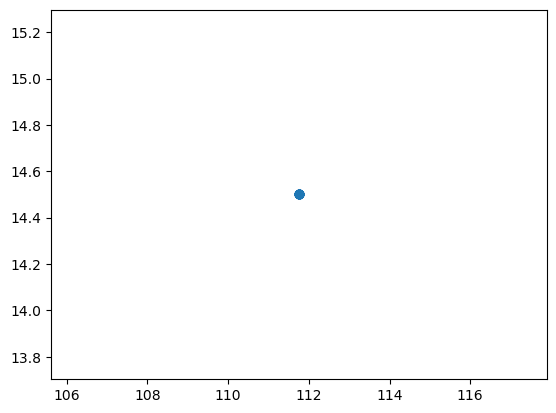

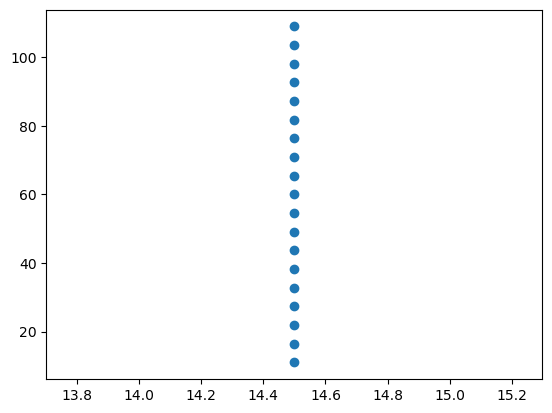

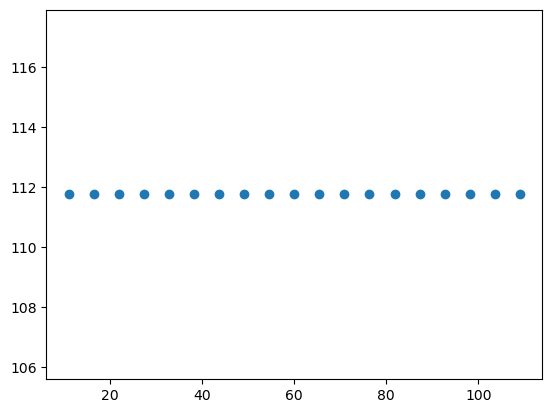

In [6]:
l1 = line_positions[:, 0]
l2 = line_positions[:, 1]
l3 = line_positions[:, 2]
plt.figure()
plt.scatter(l1, l2)

plt.figure()
plt.scatter(l2, l3)

plt.figure()
plt.scatter(l3, l1)


### Processing of data from Matlab EIDORS

In [7]:
mat_data = scipy.io.loadmat(f'{matlab_script_folder}measurement.mat')
measurement = mat_data['measurements_all']

min_values = np.min(measurement, axis=0)
max_values = np.max(measurement, axis=0)
min_max = np.stack([min_values, max_values], axis=0).T

x = np.array(measurement)
y = np.array(tip_positions[:, [0, 2]])

### Save simulation results as Pickle

In [8]:
output_file_path = "/Users/piotrblaszyk/Documents/university/MRIGI/group-project-70006/EIDORS_FEM/simulation_results.pkl"
data = (x, y)
with open(output_file_path, "wb") as file:
    pickle.dump(data, file)